# Data Analysis - Análise das Emissões da Região Sul do Brasil

Nesse notebook iremos realizar as análises do dataset "Sul.parquet", com as informações de emissão de <ins>gases de efeito estufa</ins> (GEE) dos estados da região sul do Brasil (Paraná, Santa Catarina e Rio Grande do Sul).

As análises realizadas nesse notebook serão utilizadas como base de informação para a construção do relatório final do projeto, com as conclusões contruídas.

In [1]:
import pandas as pd
import pyarrow
import matplotlib.pyplot as plt
import numpy as np

df_sul = pd.read_parquet("data/processed/Sul.parquet", engine="pyarrow", columns=["Setor de emissão", "UF", "Ano", "CO2e (t)"])

### **Séries Históricas**

As séries históricas foram geradas com dados a partir de 1990, pois antes disso não haviam dados referentes a categoria de Mudança no Uso de Terra e Floresta.

In [2]:
filtro_ano = df_sul["Ano"] >= 1990
df_sul_90 = df_sul[filtro_ano]
x = df_sul_90["Ano"].unique()

#### _Série Histórica das Emissões de GEE no Sul do Brasil:_

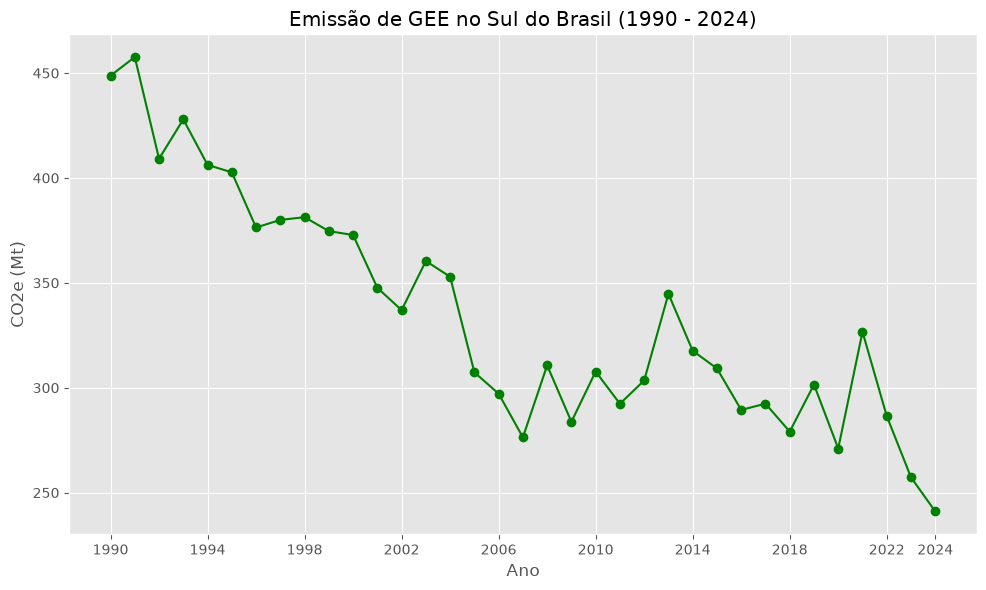

In [21]:
y_geral = (df_sul_90.groupby("Ano")[["CO2e (t)"]]
              .sum()
              .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
              / (10**6))

plt.figure(figsize=(10,6))
plt.style.use('ggplot')

plt.plot(x, y_geral,
        label="Emissão em Mega Tonelada",
        color='green',
        marker='o'
)

plt.title("Emissão de GEE no Sul do Brasil (1990 - 2024)")
plt.xlabel("Ano")
plt.ylabel("CO2e (Mt)")
plt.tight_layout()

x_ticks = np.arange(1990, 2024, step=4)
x_ticks = np.append(x_ticks, 2024)
plt.xticks(x_ticks)


plt.show()

#### _Série Histórica das Emissões de GEE por Estado no Sul do Brasil:_

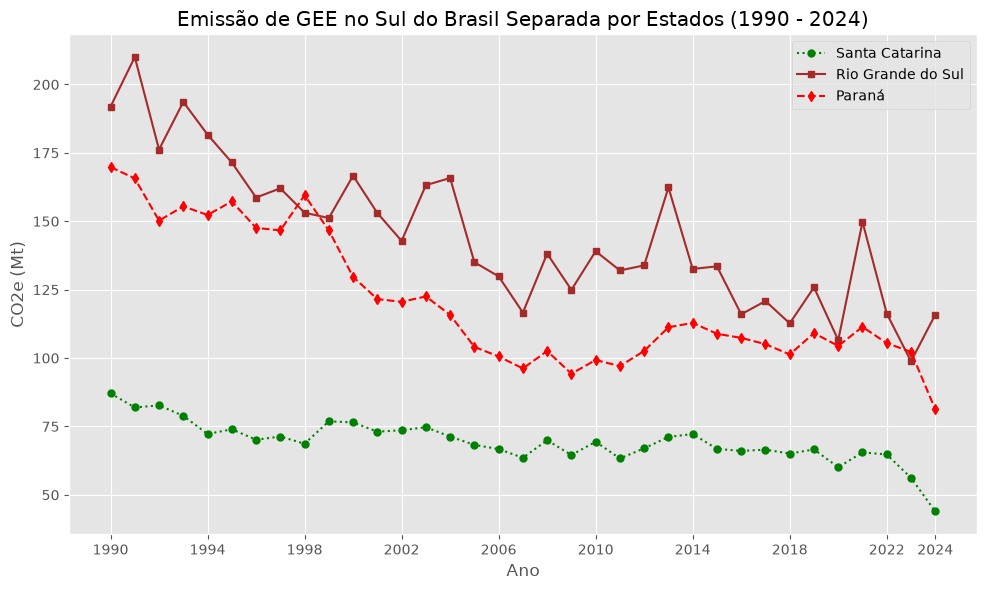

In [22]:
filtro_sc = df_sul_90["UF"] == "SC"
y_sc = (df_sul_90[filtro_sc].groupby("Ano")[["CO2e (t)"]]
                            .sum()
                            .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                            / (10**6))

filtro_rs = df_sul_90["UF"] == "RS"
y_rs= (df_sul_90[filtro_rs].groupby("Ano")[["CO2e (t)"]]
                           .sum()
                           .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                           / (10**6))

filtro_pr = df_sul_90["UF"] == "PR"
y_pr = (df_sul_90[filtro_pr].groupby("Ano")[["CO2e (t)"]]
                            .sum()
                            .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                            / (10**6))

plt.figure(figsize=(10,6))
plt.style.use('ggplot')

plt.plot(x, y_sc,
        label='Santa Catarina',
        color='green',
        linestyle=':',
        marker='o',
        markersize=5)

plt.plot(x, y_rs,
        label='Rio Grande do Sul',
        color='brown',
        linestyle='-',
        marker='s',
        markersize=5)

plt.plot(x, y_pr,
        label='Paraná',
        color='red',
        linestyle='--',
        marker='d',
        markersize=5)

plt.title("Emissão de GEE no Sul do Brasil Separada por Estados (1990 - 2024)")
plt.xlabel("Ano")
plt.ylabel("CO2e (Mt)")
plt.legend(labelcolor='black')
plt.tight_layout()

x_ticks = np.arange(1990, 2024, step=4) # Definindo o início, o fim e o intervalo entre cada ponto do eixo X. Em resumo, os valores que aparecem
x_ticks = np.append(x_ticks, 2024)      # discriminados no eixo X.

plt.xticks(x_ticks)

plt.show()

#### _Série Histórica de Cada Setor de Emissão no Sul do Brasil:_

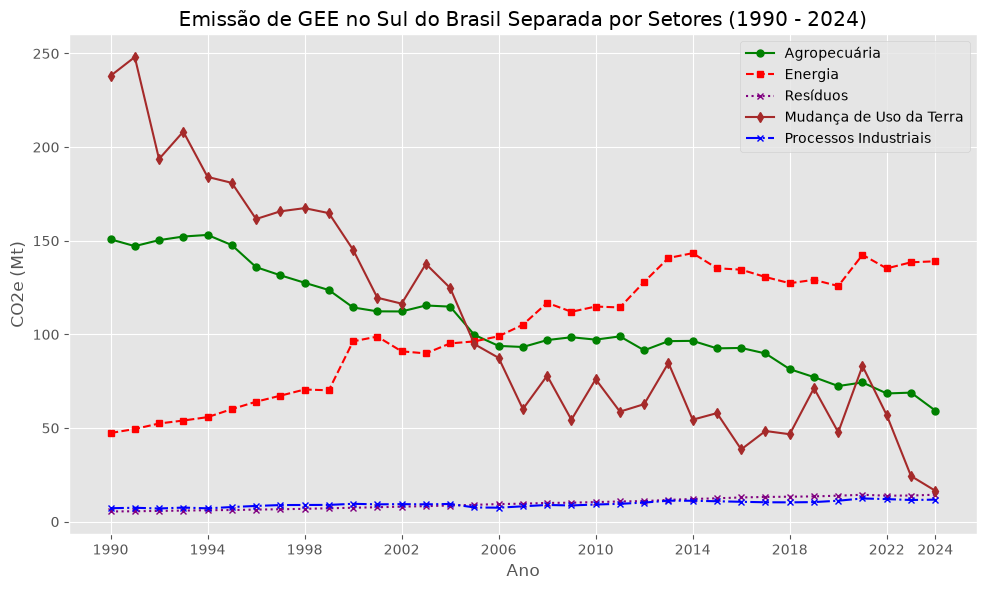

In [23]:
filtro_agro = df_sul_90["Setor de emissão"] == "Agropecuária"
y_agro = (df_sul_90[filtro_agro].groupby("Ano")[["CO2e (t)"]]
                                .sum()
                                .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                 /(10**6))                                  # Dividimos por 10 elevado a 6 para transformar a unidade para Mega Tonelada, removendo a notação científica.

filtro_energia = df_sul_90["Setor de emissão"] == "Energia"
y_energia = (df_sul_90[filtro_energia].groupby("Ano")[["CO2e (t)"]]
                                      .sum()
                                      .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                       /(10**6))

filtro_uso_terra = df_sul_90["Setor de emissão"] == "Mudança de Uso da Terra e Floresta"
y_uso_terra = (df_sul_90[filtro_uso_terra].groupby("Ano")[["CO2e (t)"]]
                                          .sum()
                                          .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                           /(10**6))

filtro_residuos = df_sul_90["Setor de emissão"] == "Resíduos"
y_residuos = (df_sul_90[filtro_residuos].groupby("Ano")[["CO2e (t)"]]
                                        .sum()
                                        .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                         /(10**6))

filtro_industriais = df_sul_90["Setor de emissão"] == "Processos Industriais"
y_industriais = (df_sul_90[filtro_industriais].groupby("Ano")[["CO2e (t)"]]
                                              .sum()
                                              .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                               /(10**6))

plt.figure(figsize=(10,6))
plt.style.use('ggplot')

plt.plot(x, y_agro,
        label='Agropecuária',
        color='green',
        linestyle='-',
        marker='o',
        markersize=5)

plt.plot(x, y_energia,
        label='Energia',
        color='red',
        linestyle='--',
        marker='s',
        markersize=5)

plt.plot(x, y_residuos,
        label='Resíduos',
        color='purple',
        linestyle=':',
        marker='x',
        markersize=5)

plt.plot(x, y_uso_terra,
        label='Mudança de Uso da Terra',
        color='brown',
        linestyle='-',
        marker='d',
        markersize=5)

plt.plot(x, y_industriais,
        label='Processos Industriais',
        color='blue',
        linestyle='-.',
        marker='x',
        markersize=5)

plt.title("Emissão de GEE no Sul do Brasil Separada por Setores (1990 - 2024)")
plt.xlabel("Ano")
plt.ylabel("CO2e (Mt)")
plt.legend(labelcolor='black')
plt.tight_layout()

x_ticks = np.arange(1990, 2024, step=4) # Definindo o início, o fim e o intervalo entre cada ponto do eixo X. Em resumo, os valores que aparecem
x_ticks = np.append(x_ticks, 2024)      # discriminados no eixo X.

plt.xticks(x_ticks)

plt.show()

### Séries Históricas por Setor e por Estado no Sul do Brasil:

### **Santa Catarina**

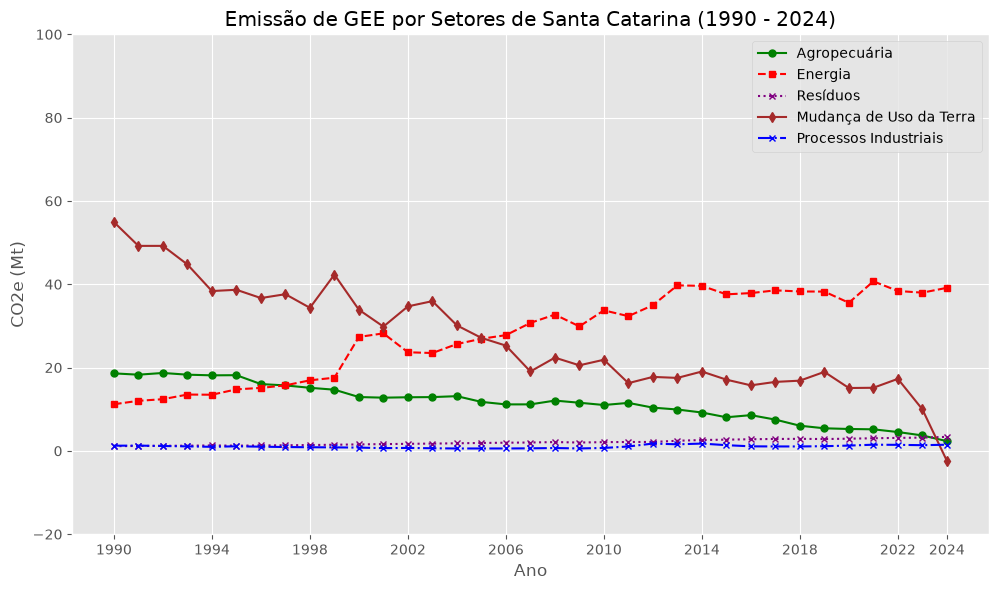

In [24]:
df_sc = df_sul_90[filtro_sc]

filtro_agro = df_sc["Setor de emissão"] == "Agropecuária"
y_agro = (df_sc[filtro_agro].groupby("Ano")[["CO2e (t)"]]
                            .sum()
                            .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                             /(10**6))                                  # Dividimos por 10 elevado a 6 para transformar a unidade para Mega Tonelada, removendo a notação científica.

filtro_energia = df_sc["Setor de emissão"] == "Energia"
y_energia = (df_sc[filtro_energia].groupby("Ano")[["CO2e (t)"]]
                                  .sum()
                                  .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                   /(10**6))

filtro_uso_terra = df_sc["Setor de emissão"] == "Mudança de Uso da Terra e Floresta"
y_uso_terra = (df_sc[filtro_uso_terra].groupby("Ano")[["CO2e (t)"]]
                                      .sum()
                                      .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                       /(10**6))

filtro_residuos = df_sc["Setor de emissão"] == "Resíduos"
y_residuos = (df_sc[filtro_residuos].groupby("Ano")[["CO2e (t)"]]
                                    .sum()
                                    .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                     /(10**6))

filtro_industriais = df_sc["Setor de emissão"] == "Processos Industriais"
y_industriais = (df_sc[filtro_industriais].groupby("Ano")[["CO2e (t)"]]
                                          .sum()
                                          .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                           /(10**6))

plt.figure(figsize=(10,6))
plt.style.use('ggplot')

plt.plot(x, y_agro,
        label='Agropecuária',
        color='green',
        linestyle='-',
        marker='o',
        markersize=5)

plt.plot(x, y_energia,
        label='Energia',
        color='red',
        linestyle='--',
        marker='s',
        markersize=5)

plt.plot(x, y_residuos,
        label='Resíduos',
        color='purple',
        linestyle=':',
        marker='x',
        markersize=5)

plt.plot(x, y_uso_terra,
        label='Mudança de Uso da Terra',
        color='brown',
        linestyle='-',
        marker='d',
        markersize=5)

plt.plot(x, y_industriais,
        label='Processos Industriais',
        color='blue',
        linestyle='-.',
        marker='x',
        markersize=5)

plt.title("Emissão de GEE por Setores de Santa Catarina (1990 - 2024)")
plt.xlabel("Ano")
plt.ylabel("CO2e (Mt)")
plt.legend(labelcolor='black')
plt.tight_layout()

x_ticks = np.arange(1990, 2024, step=4)
x_ticks = np.append(x_ticks, 2024)     

y_ticks = np.arange(-20, 120, step=20) 

plt.xticks(x_ticks)
plt.yticks(y_ticks)

plt.show()

### **Paraná**

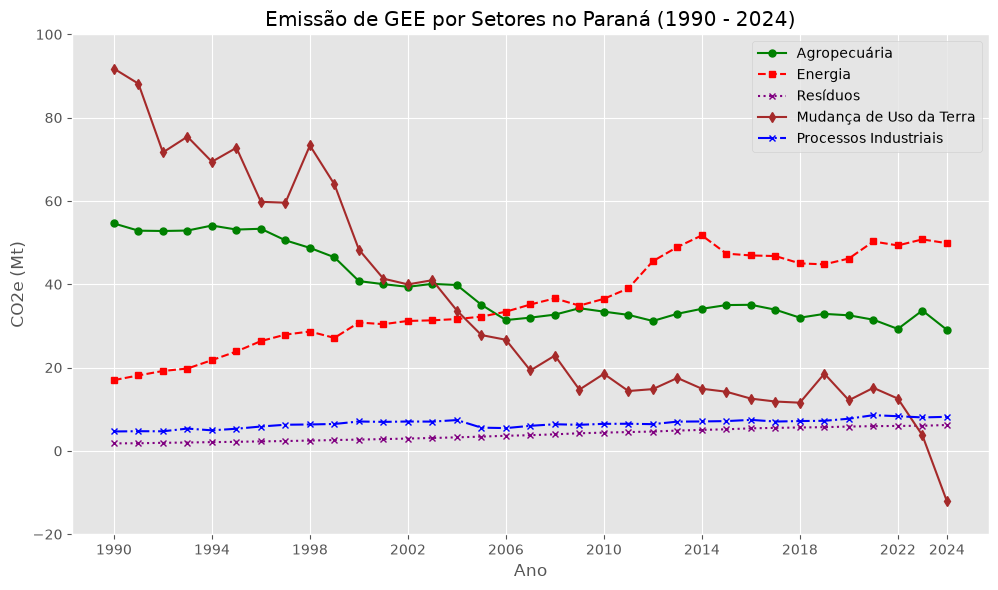

In [25]:
df_pr = df_sul_90[filtro_pr]

filtro_agro = df_pr["Setor de emissão"] == "Agropecuária"
y_agro = (df_pr[filtro_agro].groupby("Ano")[["CO2e (t)"]]
                            .sum()
                            .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                             /(10**6))                                  # Dividimos por 10 elevado a 6 para transformar a unidade para Mega Tonelada, removendo a notação científica.

filtro_energia = df_pr["Setor de emissão"] == "Energia"
y_energia = (df_pr[filtro_energia].groupby("Ano")[["CO2e (t)"]]
                                  .sum()
                                  .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                   /(10**6))

filtro_uso_terra = df_pr["Setor de emissão"] == "Mudança de Uso da Terra e Floresta"
y_uso_terra = (df_pr[filtro_uso_terra].groupby("Ano")[["CO2e (t)"]]
                                      .sum()
                                      .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                       /(10**6))

filtro_residuos = df_pr["Setor de emissão"] == "Resíduos"
y_residuos = (df_pr[filtro_residuos].groupby("Ano")[["CO2e (t)"]]
                                    .sum()
                                    .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                     /(10**6))

filtro_industriais = df_pr["Setor de emissão"] == "Processos Industriais"
y_industriais = (df_pr[filtro_industriais].groupby("Ano")[["CO2e (t)"]]
                                          .sum()
                                          .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                           /(10**6))

plt.figure(figsize=(10,6))
plt.style.use('ggplot')

plt.plot(x, y_agro,
        label='Agropecuária',
        color='green',
        linestyle='-',
        marker='o',
        markersize=5)

plt.plot(x, y_energia,
        label='Energia',
        color='red',
        linestyle='--',
        marker='s',
        markersize=5)

plt.plot(x, y_residuos,
        label='Resíduos',
        color='purple',
        linestyle=':',
        marker='x',
        markersize=5)

plt.plot(x, y_uso_terra,
        label='Mudança de Uso da Terra',
        color='brown',
        linestyle='-',
        marker='d',
        markersize=5)

plt.plot(x, y_industriais,
        label='Processos Industriais',
        color='blue',
        linestyle='-.',
        marker='x',
        markersize=5)

plt.title("Emissão de GEE por Setores no Paraná (1990 - 2024)")
plt.xlabel("Ano")
plt.ylabel("CO2e (Mt)")
plt.legend(labelcolor='black')
plt.tight_layout()

x_ticks = np.arange(1990, 2024, step=4) # Definindo o início, o fim e o intervalo entre cada ponto do eixo X. Em resumo, os valores que aparecem
x_ticks = np.append(x_ticks, 2024)      # discriminados no eixo X.

plt.xticks(x_ticks)
plt.yticks(y_ticks)

plt.show()

### **Rio Grande do Sul**

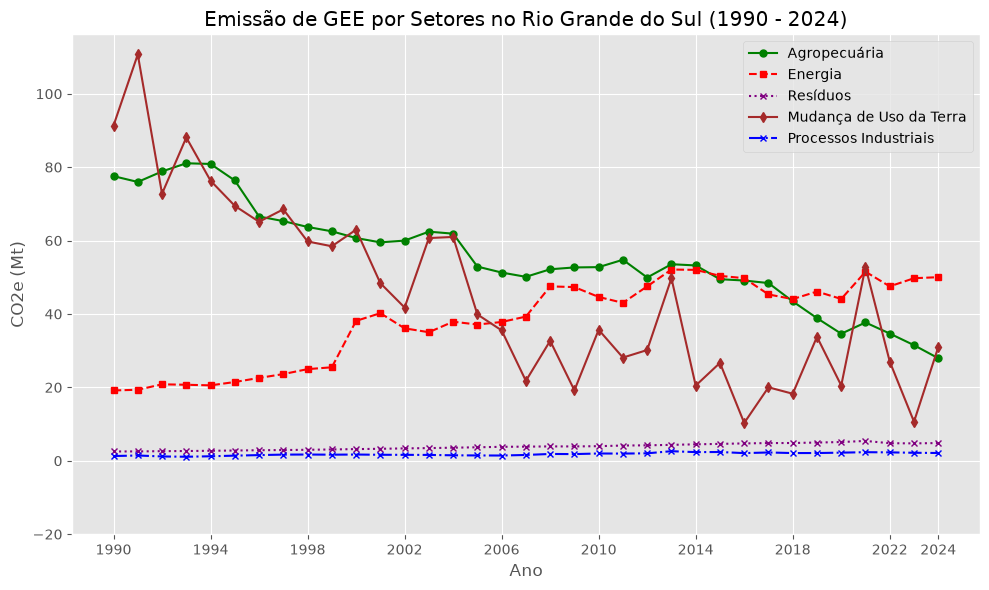

In [26]:
df_rs = df_sul_90[filtro_rs]

filtro_agro = df_rs["Setor de emissão"] == "Agropecuária"
y_agro = (df_rs[filtro_agro].groupby("Ano")[["CO2e (t)"]]
                            .sum()
                            .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                             /(10**6))                                  # Dividimos por 10 elevado a 6 para transformar a unidade para Mega Tonelada, removendo a notação científica.

filtro_energia = df_rs["Setor de emissão"] == "Energia"
y_energia = (df_rs[filtro_energia].groupby("Ano")[["CO2e (t)"]]
                                  .sum()
                                  .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                   /(10**6))

filtro_uso_terra = df_rs["Setor de emissão"] == "Mudança de Uso da Terra e Floresta"
y_uso_terra = (df_rs[filtro_uso_terra].groupby("Ano")[["CO2e (t)"]]
                                      .sum()
                                      .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                       /(10**6))

filtro_residuos = df_rs["Setor de emissão"] == "Resíduos"
y_residuos = (df_rs[filtro_residuos].groupby("Ano")[["CO2e (t)"]]
                                    .sum()
                                    .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                     /(10**6))

filtro_industriais = df_rs["Setor de emissão"] == "Processos Industriais"
y_industriais = (df_rs[filtro_industriais].groupby("Ano")[["CO2e (t)"]]
                                          .sum()
                                          .rename(columns={"CO2e (t)" : "CO2e (Mt)"})
                                           /(10**6))

plt.figure(figsize=(10,6))
plt.style.use('ggplot')

plt.plot(x, y_agro,
        label='Agropecuária',
        color='green',
        linestyle='-',
        marker='o',
        markersize=5)

plt.plot(x, y_energia,
        label='Energia',
        color='red',
        linestyle='--',
        marker='s',
        markersize=5)

plt.plot(x, y_residuos,
        label='Resíduos',
        color='purple',
        linestyle=':',
        marker='x',
        markersize=5)

plt.plot(x, y_uso_terra,
        label='Mudança de Uso da Terra',
        color='brown',
        linestyle='-',
        marker='d',
        markersize=5)

plt.plot(x, y_industriais,
        label='Processos Industriais',
        color='blue',
        linestyle='-.',
        marker='x',
        markersize=5)

plt.title("Emissão de GEE por Setores no Rio Grande do Sul (1990 - 2024)")
plt.xlabel("Ano")
plt.ylabel("CO2e (Mt)")
plt.legend(labelcolor='black')
plt.tight_layout()

x_ticks = np.arange(1990, 2024, step=4) # Definindo o início, o fim e o intervalo entre cada ponto do eixo X. Em resumo, os valores que aparecem
x_ticks = np.append(x_ticks, 2024)      # discriminados no eixo X.

plt.xticks(x_ticks)
plt.yticks(y_ticks)

plt.show()

### **Gráfico de Barras por Setor e Evolução da Emissão Líquida de GEE**

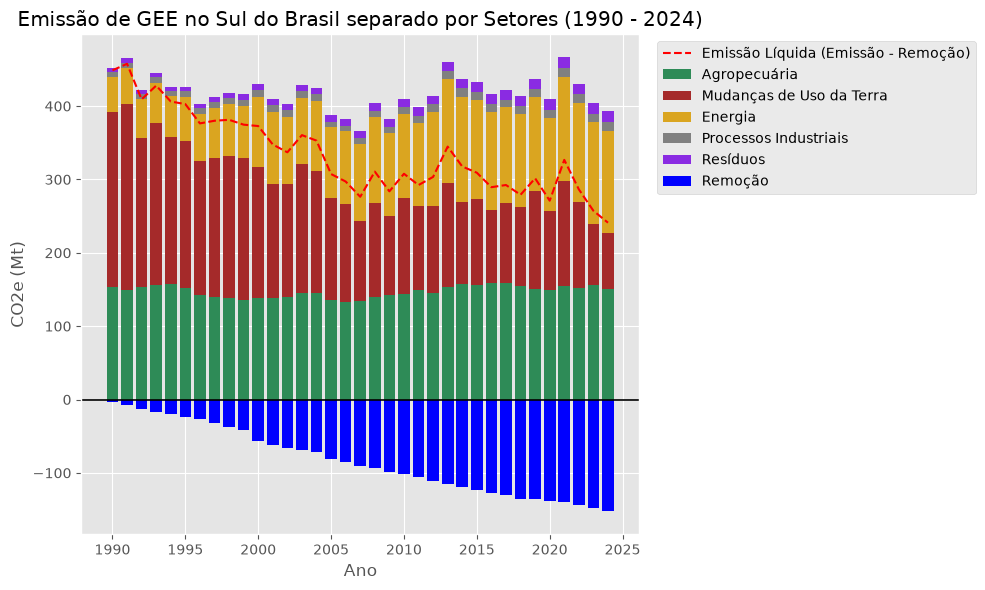

In [28]:
y_geral = (df_sul_90.groupby("Ano")["CO2e (t)"]
                    .sum()
                    / (10**6))

filtro_agro = (df_sul_90["Setor de emissão"] == "Agropecuária") & (df_sul_90["CO2e (t)"] > 0)
y_agro = (df_sul_90[filtro_agro].groupby("Ano")["CO2e (t)"]
                                .sum()
                                 /(10**6))

filtro_energia = (df_sul_90["Setor de emissão"] == "Energia") & (df_sul_90["CO2e (t)"] > 0)
y_energia = (df_sul_90[filtro_energia].groupby("Ano")["CO2e (t)"]
                                      .sum()
                                       /(10**6))

filtro_uso_terra = (df_sul_90["Setor de emissão"] == "Mudança de Uso da Terra e Floresta") & (df_sul_90["CO2e (t)"] > 0)
y_uso_terra = (df_sul_90[filtro_uso_terra].groupby("Ano")["CO2e (t)"]
                                          .sum()
                                           /(10**6))

filtro_residuos = (df_sul_90["Setor de emissão"] == "Resíduos") & (df_sul_90["CO2e (t)"] > 0)
y_residuos = (df_sul_90[filtro_residuos].groupby("Ano")["CO2e (t)"]
                                        .sum()
                                         /(10**6))

filtro_industriais = (df_sul_90["Setor de emissão"] == "Processos Industriais") & (df_sul_90["CO2e (t)"] > 0)
y_industriais = (df_sul_90[filtro_industriais].groupby("Ano")["CO2e (t)"]
                                              .sum()
                                               /(10**6))

filtro_remocao = df_sul_90["CO2e (t)"] < 0
y_remocao = (df_sul_90[filtro_remocao].groupby("Ano")["CO2e (t)"]
                                      .sum()
                                      / (10**6))

plt.figure(figsize=(10,6))
plt.style.use('ggplot')

plt.bar(x, y_agro,
        label="Agropecuária",
        color='seagreen')

plt.bar(x, y_uso_terra,
        bottom=y_agro,
        label="Mudanças de Uso da Terra",
        color='brown')

plt.bar(x, y_energia,
        bottom=y_agro + y_uso_terra,
        label="Energia",
        color='goldenrod')

plt.bar(x, y_industriais,
        bottom=y_agro + y_uso_terra + y_energia,
        label="Processos Industriais",
        color='gray')

plt.bar(x, y_residuos,
        bottom=y_agro + y_uso_terra + y_energia + y_industriais,
        label="Resíduos",
        color='blueviolet')

plt.bar(x, y_remocao,
        label="Remoção",
        color='blue')

plt.plot(x, y_geral,
         label="Emissão Líquida (Emissão - Remoção)",
         linestyle="--",
         color='red')

plt.axhline(y=0, color='black', linewidth=1.2)

plt.title("Emissão de GEE no Sul do Brasil separado por Setores (1990 - 2024)")
plt.ylabel("CO2e (Mt)")
plt.xlabel("Ano")

plt.legend(
        labelcolor='black',
        loc='upper left',
        bbox_to_anchor=(1.02, 1))

plt.tight_layout()

plt.show()